Amostras carregadas: 15

Amostras por cenário:
cenario
cidade_densa                5
cidade_densa_vento_forte    5
cidade_limpa                5
Name: count, dtype: int64

Resumo estatístico por cenário:
                         nos_astar          tempo_astar_s        custo_astar  \
                              mean      std          mean    std        mean   
cenario                                                                        
cidade_densa                 149.6   95.976         0.001  0.001        23.2   
cidade_densa_vento_forte     241.8  191.892         0.002  0.002        49.0   
cidade_limpa                 271.8  235.954         0.002  0.002        27.1   

                                 passos_astar        nos_bfs           \
                             std         mean    std    mean      std   
cenario                                                                 
cidade_densa               5.239         15.8  3.493   725.2  314.853   
cidade_densa_vento_fort

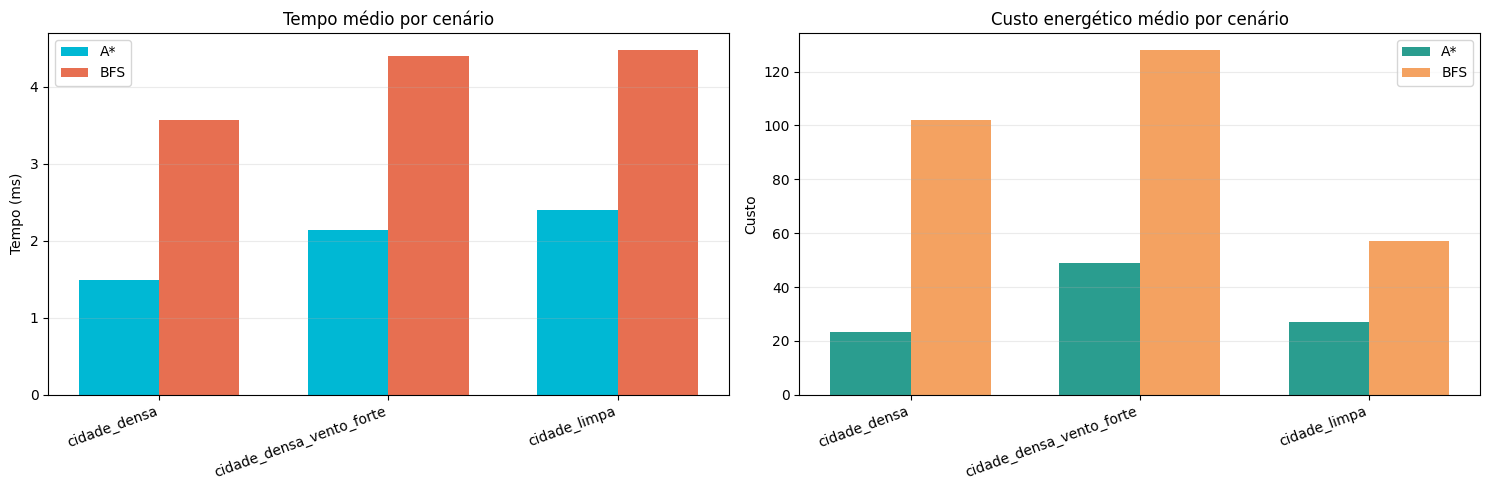

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path('resultados.csv')
if not csv_path.exists():
    raise FileNotFoundError(f'Arquivo não encontrado: {csv_path.resolve()}')

df = pd.read_csv(csv_path)

colunas_numericas = [
    'nos_astar',
    'tempo_astar_s',
    'custo_astar',
    'passos_astar',
    'nos_bfs',
    'tempo_bfs_s',
    'custo_bfs',
    'passos_bfs',
    'nos_tempo_real',
    'replanejamentos',
]

for coluna in colunas_numericas:
    df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

print('Amostras carregadas:', len(df))
print('\nAmostras por cenário:')
print(df['cenario'].value_counts().sort_index())

resumo = (
    df.groupby('cenario')[colunas_numericas]
    .agg(['mean', 'std'])
    .round(3)
)

print('\nResumo estatístico por cenário:')
print(resumo)

resumo_plano = (
    df.groupby('cenario')[[
        'nos_astar', 'tempo_astar_s', 'custo_astar', 'passos_astar',
        'nos_bfs', 'tempo_bfs_s', 'custo_bfs', 'passos_bfs',
        'nos_tempo_real', 'replanejamentos'
    ]]
    .mean()
    .round(2)
    .reset_index()
)

resumo_plano['tempo_astar_ms'] = (df.groupby('cenario')['tempo_astar_s'].mean() * 1000).round(3).values
resumo_plano['tempo_bfs_ms'] = (df.groupby('cenario')['tempo_bfs_s'].mean() * 1000).round(3).values

print('\nTabela consolidada das médias por cenário:')
print(resumo_plano)

fig, eixos = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(resumo_plano['cenario']))
largura = 0.35

eixos[0].bar(x - largura / 2, resumo_plano['tempo_astar_ms'], largura, label='A*', color='#00B8D4')
eixos[0].bar(x + largura / 2, resumo_plano['tempo_bfs_ms'], largura, label='BFS', color='#E76F51')
eixos[0].set_title('Tempo médio por cenário')
eixos[0].set_ylabel('Tempo (ms)')
eixos[0].set_xticks(x)
eixos[0].set_xticklabels(resumo_plano['cenario'], rotation=20, ha='right')
eixos[0].legend()
eixos[0].grid(axis='y', alpha=0.25)

eixos[1].bar(x - largura / 2, resumo_plano['custo_astar'], largura, label='A*', color='#2A9D8F')
eixos[1].bar(x + largura / 2, resumo_plano['custo_bfs'], largura, label='BFS', color='#F4A261')
eixos[1].set_title('Custo energético médio por cenário')
eixos[1].set_ylabel('Custo')
eixos[1].set_xticks(x)
eixos[1].set_xticklabels(resumo_plano['cenario'], rotation=20, ha='right')
eixos[1].legend()
eixos[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()
